# RescueVision Edge — Inference Notebook
**Hackathon FindIT! 2026 — Track A: The Edge Vision**

Script bersih untuk load model dan deteksi korban dari citra drone.  
Berjalan **sepenuhnya offline, CPU-only** menggunakan ONNX Runtime.

**Requirements:**
- `model/best.onnx` sudah tersedia (dari training.ipynb)
- `onnxruntime`, `opencv-python`, `numpy`, `matplotlib`
- Tidak memerlukan PyTorch atau GPU

## 1. Setup & Model Load

In [1]:
import os
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import onnxruntime as ort
from pathlib import Path

# Setup working dir
if not os.path.exists('runs/detect/runs/train/rescuevision_v13/weights/best.onnx'):
    os.chdir('..')
assert os.path.exists('model/best.onnx'), 'STOP: model/best.onnx tidak ditemukan. Jalankan training.ipynb dulu.'

print(f'Working dir : {os.getcwd()}')
print(
    f'Model size  : {os.path.getsize("runs/detect/runs/train/rescuevision_v13/weights/best.onnx") / (1024**2):.2f} MB'
)
print(f"ONNX Runtime: {ort.__version__}")

Working dir : c:\Users\MASTER CORE\RescueVision
Model size  : 11.70 MB
ONNX Runtime: 1.23.2


In [2]:
# ============================================================
# INFERENCE CONFIG
# ============================================================
MODEL_PATH = "runs/detect/runs/train/rescuevision_v13/weights/best.onnx"
INPUT_SIZE   = 640         # harus sama dengan saat training
CONF_THRESH  = 0.25        # confidence threshold
IOU_THRESH   = 0.45        # NMS IoU threshold
CLASS_NAMES  = ['pedestrian']

# Load model — force CPU provider
session = ort.InferenceSession(
    MODEL_PATH,
    providers=['CPUExecutionProvider']   # C-A2: CPU-only
)

input_name  = session.get_inputs()[0].name
input_shape = session.get_inputs()[0].shape
print(f'Model loaded: {MODEL_PATH}')
print(f'Input name  : {input_name}')
print(f'Input shape : {input_shape}')
print(f'Providers   : {session.get_providers()}')

Model loaded: runs/detect/runs/train/rescuevision_v13/weights/best.onnx
Input name  : images
Input shape : [1, 3, 640, 640]
Providers   : ['CPUExecutionProvider']


## 2. Preprocessing & Inference Functions

In [3]:
def preprocess(image_path: str, input_size: int = 640):
    """
    Load & preprocess image untuk YOLOv8 inference.
    Returns: (input_tensor, original_image, scale, pad_x, pad_y)
    """
    img_bgr  = cv2.imread(image_path)
    if img_bgr is None:
        raise ValueError(f'Cannot read image: {image_path}')
    
    orig_h, orig_w = img_bgr.shape[:2]
    
    # Letterbox resize (preserve aspect ratio)
    scale = min(input_size / orig_w, input_size / orig_h)
    new_w = int(orig_w * scale)
    new_h = int(orig_h * scale)
    pad_x = (input_size - new_w) // 2
    pad_y = (input_size - new_h) // 2
    
    img_resized = cv2.resize(img_bgr, (new_w, new_h))
    img_padded  = np.full((input_size, input_size, 3), 114, dtype=np.uint8)
    img_padded[pad_y:pad_y+new_h, pad_x:pad_x+new_w] = img_resized
    
    img_rgb  = cv2.cvtColor(img_padded, cv2.COLOR_BGR2RGB)
    img_norm = img_rgb.astype(np.float32) / 255.0
    img_chw  = np.transpose(img_norm, (2, 0, 1))
    img_batch = np.expand_dims(img_chw, axis=0)
    
    return img_batch, img_bgr, scale, pad_x, pad_y


def non_max_suppression(boxes, scores, iou_threshold):
    """Simple NMS implementation"""
    if len(boxes) == 0:
        return []
    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]
    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]
    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        inter = np.maximum(0, xx2 - xx1) * np.maximum(0, yy2 - yy1)
        iou = inter / (areas[i] + areas[order[1:]] - inter)
        order = order[1:][iou <= iou_threshold]
    return keep


def postprocess(output, orig_img, scale, pad_x, pad_y,
                conf_thresh=0.25, iou_thresh=0.45):
    """
    Postprocess YOLOv8 ONNX output.
    YOLOv8 output shape: [1, 5, num_anchors] (cx, cy, w, h, conf)
    Returns list of (x1, y1, x2, y2, confidence) in original image coords.
    """
    preds = output[0]  # [1, 5, N] or [1, 84, N]
    if preds.ndim == 3:
        preds = preds[0]  # [5, N] or [84, N]
    
    # YOLOv8 single-class: rows = [cx, cy, w, h, conf]
    cx   = preds[0, :]
    cy   = preds[1, :]
    w    = preds[2, :]
    h    = preds[3, :]
    conf = preds[4, :]
    
    mask = conf > conf_thresh
    cx, cy, w, h, conf = cx[mask], cy[mask], w[mask], h[mask], conf[mask]
    
    if len(conf) == 0:
        return []
    
    # Convert to x1,y1,x2,y2 (in padded-resized coords)
    x1 = cx - w / 2
    y1 = cy - h / 2
    x2 = cx + w / 2
    y2 = cy + h / 2
    
    boxes_arr = np.stack([x1, y1, x2, y2], axis=1)
    keep = non_max_suppression(boxes_arr, conf, iou_thresh)
    
    orig_h, orig_w = orig_img.shape[:2]
    detections = []
    for i in keep:
        # Unpad and unscale to original image coords
        ox1 = max(0, (boxes_arr[i, 0] - pad_x) / scale)
        oy1 = max(0, (boxes_arr[i, 1] - pad_y) / scale)
        ox2 = min(orig_w, (boxes_arr[i, 2] - pad_x) / scale)
        oy2 = min(orig_h, (boxes_arr[i, 3] - pad_y) / scale)
        detections.append((ox1, oy1, ox2, oy2, float(conf[i])))
    
    return detections


def run_inference(image_path: str):
    """
    Full inference pipeline. Returns (detections, inference_time_ms).
    detections = list of (x1, y1, x2, y2, confidence)
    """
    tensor, orig_img, scale, pad_x, pad_y = preprocess(image_path, INPUT_SIZE)
    
    t_start = time.perf_counter()
    output = session.run(None, {input_name: tensor})
    t_infer = (time.perf_counter() - t_start) * 1000
    
    detections = postprocess(output, orig_img, scale, pad_x, pad_y,
                             CONF_THRESH, IOU_THRESH)
    return detections, t_infer, orig_img


print('Functions defined ✅')

Functions defined ✅


## 3. Single Image Inference

In [4]:
# ==================================================
# Ganti path ini dengan gambar yang ingin dideteksi
# ==================================================
test_images = list(Path('test_data/images').glob('*.jpg'))[:5]
TEST_IMAGE  = str(test_images[0]) if test_images else 'test_data/images/sample.jpg'

print(f'Running inference on: {TEST_IMAGE}')
detections, t_ms, orig_img = run_inference(TEST_IMAGE)

print(f'\nInference time : {t_ms:.1f} ms  (limit: 3000 ms)')
print(f'Detections     : {len(detections)} pedestrian(s)')

# Constraint check
if t_ms <= 3000:
    print(f'✅ Constraint C-A3 PASS: {t_ms:.1f} ms ≤ 3000 ms')
else:
    print(f'❌ Constraint C-A3 FAIL: {t_ms:.1f} ms > 3000 ms')

# Display detections
print('\nDetections (x1, y1, x2, y2, confidence):')
for i, (x1, y1, x2, y2, conf) in enumerate(detections):
    print(f'  [{i+1}] ({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f}) conf={conf:.3f}')

Running inference on: test_data\images\0000006_00159_d_0000001.jpg

Inference time : 41.5 ms  (limit: 3000 ms)
Detections     : 3 pedestrian(s)
✅ Constraint C-A3 PASS: 41.5 ms ≤ 3000 ms

Detections (x1, y1, x2, y2, confidence):
  [1] (1040.6, 161.2, 1048.6, 175.1) conf=0.460
  [2] (865.3, 155.4, 871.8, 170.5) conf=0.440
  [3] (1134.8, 161.1, 1141.3, 174.8) conf=0.437


## 4. Visualization

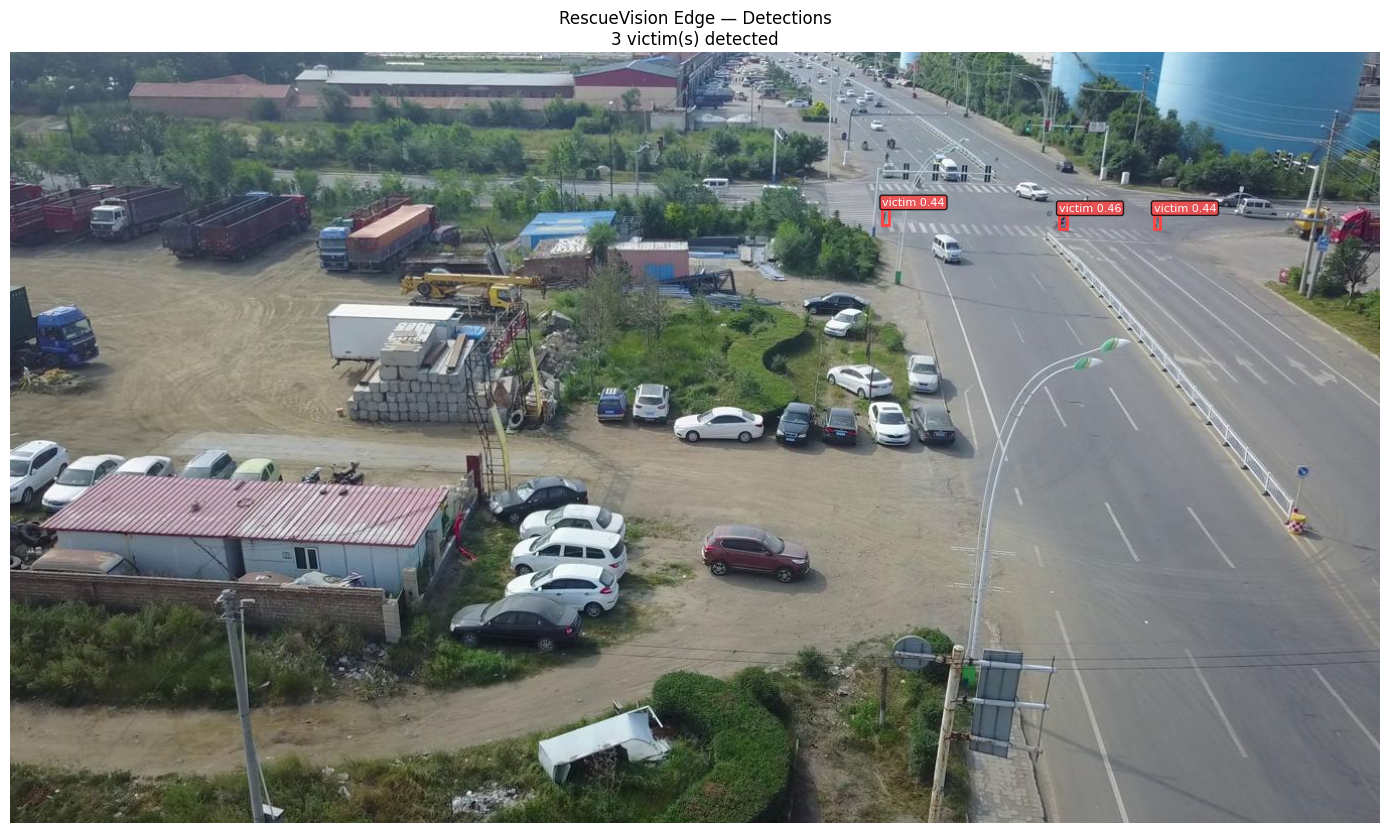

In [5]:
def visualize(img_bgr, detections, title='RescueVision Edge — Detections'):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    ax.imshow(img_rgb)
    
    for (x1, y1, x2, y2, conf) in detections:
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor='#FF4444', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, f'victim {conf:.2f}',
                fontsize=8, color='white',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#FF4444', alpha=0.8))
    
    ax.set_title(f'{title}\n{len(detections)} victim(s) detected', fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

visualize(orig_img, detections)

## 5. Batch Inference on Test Set

In [6]:
test_imgs = list(Path('test_data/images').glob('*.jpg'))[:30]
print(f'Running inference on {len(test_imgs)} test images...\n')

all_times = []
total_detections = 0

for img_path in test_imgs:
    dets, t_ms, _ = run_inference(str(img_path))
    all_times.append(t_ms)
    total_detections += len(dets)

print('=== BATCH INFERENCE RESULTS ===')
print(f'Images processed   : {len(test_imgs)}')
print(f'Total detections   : {total_detections}')
print(f'Mean time/image    : {np.mean(all_times):.1f} ms')
print(f'Max  time/image    : {np.max(all_times):.1f} ms')
print(f'P95  time/image    : {np.percentile(all_times, 95):.1f} ms')
print(f'\nConstraint C-A3    : max {np.max(all_times):.1f} ms ≤ 3000 ms → {"✅ PASS" if np.max(all_times) <= 3000 else "❌ FAIL"}')

Running inference on 30 test images...

=== BATCH INFERENCE RESULTS ===
Images processed   : 30
Total detections   : 1069
Mean time/image    : 31.9 ms
Max  time/image    : 38.1 ms
P95  time/image    : 33.9 ms

Constraint C-A3    : max 38.1 ms ≤ 3000 ms → ✅ PASS
